In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


True

In [2]:
import kagglehub

path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")
df = pd.read_csv(f"{path}/fake_job_postings.csv")

print(f"Dataset loaded: {df.shape}")
print(f"Fraud distribution:")
print(df['fraudulent'].value_counts())
print(f"Fraud rate: {df['fraudulent'].mean()*100:.2f}%")


100%|██████████| 16.1M/16.1M [00:00<00:00, 29.3MB/s]

Extracting files...


Dataset loaded: (17880, 18)
Fraud distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64
Fraud rate: 4.84%


# Combine all text fields (@Anshupriya2694's approach)

In [3]:
def combine_text_fields(row):
    fields = [
        'title', 'location', 'company_profile', 'description',
        'requirements', 'benefits', 'required_experience',
        'required_education', 'industry', 'function'
    ]

    text_parts = []
    for field in fields:
        if pd.notna(row[field]):
            text_parts.append(str(row[field]))

    return ' '.join(text_parts) if text_parts else "unknown job"

print("Combining text fields...")
df['combined_text'] = df.apply(combine_text_fields, axis=1)
print("Done")

Combining text fields...
Done


# Preprocessing text

In [4]:
def preprocess_text(text):
    if pd.isna(text):
        return ""

    # Tokenize
    tokens = word_tokenize(str(text).lower())

    # Remove stopwords and non-alphabetic tokens
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]

    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return ' '.join(tokens)

print("Preprocessing text...")
df['text_processed'] = df['combined_text'].apply(preprocess_text)
print("Done")


Preprocessing text...
Done


# Numeric features

In [5]:
# Create location-based fraud ratio
location_fraud_ratio = (df.groupby('location')['fraudulent'].sum() /
                        df.groupby('location').size())
df['location_fraud_ratio'] = df['location'].map(location_fraud_ratio).fillna(0.05)

# Character count
df['character_count'] = df['combined_text'].str.len()


# TF-IDF Vectorizer





In [6]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    stop_words='english'
)

X_text = vectorizer.fit_transform(df['text_processed'])

print(f"TF-IDF vectorization complete:")
print(f"  Shape: {X_text.shape}")
print(f"  Sparsity: {1 - X_text.nnz / (X_text.shape[0] * X_text.shape[1]):.1%}")


TF-IDF vectorization complete:
  Shape: (17880, 5000)
  Sparsity: 96.9%


# Combining all features

In [7]:
# Numeric features (their approach)
numeric_features = [
    'telecommuting',
    'has_company_logo',
    'has_questions',
    'location_fraud_ratio',
    'character_count'
]

X_numeric = df[numeric_features].fillna(0).values
X_numeric_sparse = csr_matrix(X_numeric)

# Combine text + numeric
X_combined = hstack([X_text, X_numeric_sparse])

y = df['fraudulent'].values

print(f"Feature combination complete:")
print(f"  Text features: {X_text.shape[1]}")
print(f"  Numeric features: {len(numeric_features)}")
print(f"  Total features: {X_combined.shape[1]}")
print(f"  Samples: {X_combined.shape[0]}")


Feature combination complete:
  Text features: 5000
  Numeric features: 5
  Total features: 5005
  Samples: 17880


# Modeling

## Stratified split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Train/Test Split (Stratified):")
print(f"  Training set:")
print(f"    - Size: {X_train.shape}")
print(f"    - Fraud rate: {y_train.mean()*100:.2f}%")
print(f"    - Legitimate: {(y_train==0).sum()}")
print(f"    - Fraudulent: {(y_train==1).sum()}")
print(f"\\n  Test set:")
print(f"    - Size: {X_test.shape}")
print(f"    - Fraud rate: {y_test.mean()*100:.2f}%")
print(f"    - Legitimate: {(y_test==0).sum()}")
print(f"    - Fraudulent: {(y_test==1).sum()}")


Train/Test Split (Stratified):
  Training set:
    - Size: (12516, 5005)
    - Fraud rate: 4.84%
    - Legitimate: 11910
    - Fraudulent: 606
\n  Test set:
    - Size: (5364, 5005)
    - Fraud rate: 4.85%
    - Legitimate: 5104
    - Fraudulent: 260


## Naive Bayes

In [9]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
y_pred_proba_nb = nb_model.predict_proba(X_test)[:, 1]

# Store the confusion matrix in a variable
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("\\n" + "="*80)
print("NAÏVE BAYES (Baseline Model)")
print("="*80)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_nb):.4f}")
print(f"\\nConfusion Matrix:")
print(cm_nb)

\n================================================================================
NAÏVE BAYES (Baseline Model)
Accuracy:  0.9702
F1-Score:  0.5960
Precision: 0.8676
Recall:    0.4538
ROC-AUC:   0.8494
\nConfusion Matrix:
[[5086   18]
 [ 142  118]]


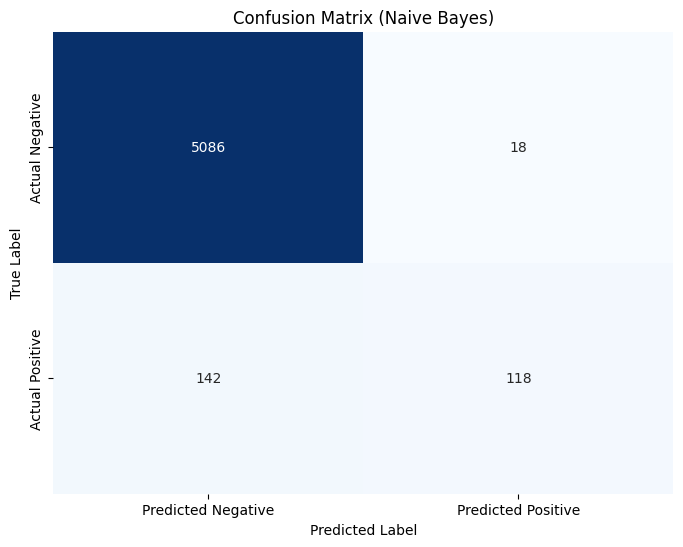

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the confusion matrix from the previous cell's output
# Assuming cm_nb is the variable holding the confusion matrix for Naive Bayes
# Replace this with the actual variable name if different
# cm = confusion_matrix(y_test, y_pred) # If you need to recalculate

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Naive Bayes)')
plt.show()

# Separate pipeline

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
from pathlib import Path

X_text = df["text_processed"]
y = df["fraudulent"]

nb_pipeline = make_pipeline(
    TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.8,
        stop_words="english",
    ),
    MultinomialNB()
)

nb_pipeline.fit(X_text, y)

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(nb_pipeline, MODELS_DIR / "nb_pipeline.pkl")


['../models/nb_pipeline.pkl']